<a href="https://colab.research.google.com/github/islombek-cs/Computer-Vision-Labs/blob/main/Week_7_8_Lab_VGG_ResNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Name:** Islombek Abdurakhmanov  
**ID:** 221236  
**Shared Colab Link:** https://colab.research.google.com/drive/1aD7ocedsKKlTmmfamYzq5dOKOkhF2c9b?usp=sharing


# Week 7-8 Lab — VGG, ResNet & U‑Net

**Goals**
- Fine‑tune **VGG16** and **ResNet18** on CIFAR‑10 (image classification).  
- Visualize **Grad‑CAM** explanations on your images.  
- Implement a lightweight **U‑Net** and train on **Oxford‑IIIT Pet** segmentation (tiny run).

> This notebook is Colab‑ready. Reduce epochs if you’re short on time/compute.



## 📚 Background & References

### VGG16 (Classification)
**Idea:** Stack many small (3×3) conv filters to increase receptive field depth with simplicity.  
**Why it matters:** Demonstrated depth + small kernels can significantly improve accuracy; widely used as a baseline.  
**Paper:** Simonyan & Zisserman, *Very Deep Convolutional Networks for Large-Scale Image Recognition* (ICLR 2015).  
- PDF: https://arxiv.org/abs/1409.1556  
- Code: https://pytorch.org/vision/stable/models/generated/torchvision.models.vgg16.html  
- Reference impl: https://github.com/pytorch/vision/tree/main/torchvision/models

### ResNet18 (Classification)
**Idea:** Residual (skip) connections to ease optimization of very deep nets by learning residual functions.  
**Why it matters:** Enables training of >100-layer nets; residual learning is foundational in modern architectures.  
**Paper:** He et al., *Deep Residual Learning for Image Recognition* (CVPR 2016).  
- PDF: https://arxiv.org/abs/1512.03385  
- Code (torchvision): https://pytorch.org/vision/stable/models/generated/torchvision.models.resnet18.html  
- Reference impl: https://github.com/pytorch/vision/tree/main/torchvision/models

### Grad‑CAM (Interpretability)
**Idea:** Uses gradients flowing into the last conv layer to produce localization maps highlighting important regions.  
**Paper:** Selvaraju et al., *Grad-CAM: Visual Explanations from Deep Networks via Gradient-based Localization* (ICCV 2017).  
- PDF: https://arxiv.org/abs/1610.02391  
- Reference: https://github.com/jacobgil/pytorch-grad-cam

### U‑Net (Semantic Segmentation)
**Idea:** Symmetric encoder–decoder with skip connections to combine semantics and precise localization.  
**Why it matters:** De-facto baseline for biomedical and small/medium-scale segmentation tasks.  
**Paper:** Ronneberger et al., *U-Net: Convolutional Networks for Biomedical Image Segmentation* (MICCAI 2015).  
- PDF: https://arxiv.org/abs/1505.04597  
- Popular PyTorch impl: https://github.com/milesial/Pytorch-UNet


In [ ]:

# ==== Setup ====
!pip -q install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
!pip -q install opencv-python tqdm

import torch, torchvision, numpy as np, cv2, time, os, math, random
import matplotlib.pyplot as plt
from tqdm import tqdm

print("Torch:", torch.__version__, "| CUDA:", torch.cuda.is_available())
device = 'cuda' if torch.cuda.is_available() else 'cpu'


Torch: 2.9.0+cu126 | CUDA: True


In [ ]:

import matplotlib.pyplot as plt
import numpy as np
import torch

def imshow_grid(images, labels=None, classes=None, ncols=8, size=(12,3)):
    n = len(images)
    nrows = int(np.ceil(n / ncols))
    plt.figure(figsize=size)
    for i in range(n):
        plt.subplot(nrows, ncols, i+1)
        img = images[i]
        if isinstance(img, torch.Tensor):
            img = img.detach().cpu().permute(1,2,0).numpy()
        img = np.clip(img, 0, 1)
        plt.imshow(img)
        if labels is not None:
            title = str(int(labels[i]))
            if classes is not None:
                title = classes[int(labels[i])]
            plt.title(title, fontsize=8)
        plt.axis('off')
    plt.tight_layout(); plt.show()



## Part A — CIFAR‑10 Dataset & Dataloaders

We’ll use standard augmentations and create train/val/test loaders.


In [ ]:

import torchvision.transforms as T
from torchvision.datasets import CIFAR10
from torch.utils.data import DataLoader, random_split

mean = (0.4914, 0.4822, 0.4465)
std  = (0.2023, 0.1994, 0.2010)

train_tf = T.Compose([
    T.RandomCrop(32, padding=4),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize(mean, std),
])

test_tf = T.Compose([T.ToTensor(), T.Normalize(mean, std)])

trainset_full = CIFAR10(root='./data', train=True, download=True, transform=train_tf)
val_size = 5000
train_size = len(trainset_full) - val_size
trainset, valset = random_split(trainset_full, [train_size, val_size])

testset = CIFAR10(root='./data', train=False, download=True, transform=test_tf)

train_loader = DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(valset,   batch_size=256, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(testset,  batch_size=256, shuffle=False, num_workers=2, pin_memory=True)

classes = trainset_full.classes
print("Train/Val/Test sizes:", train_size, val_size, len(testset))


100%|██████████| 170M/170M [00:03<00:00, 48.2MB/s]


Train/Val/Test sizes: 45000 5000 10000


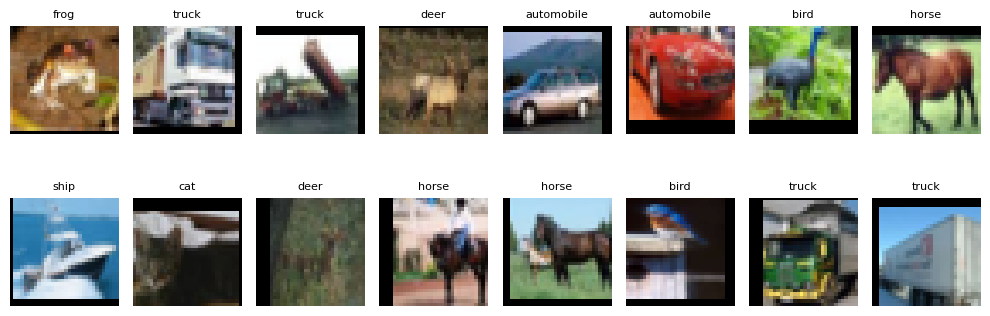

In [ ]:

# Peek at a few (unnormalized for display)
inv_norm = T.Normalize(mean=[-m/s for m,s in zip(mean,std)], std=[1/s for s in std])
sample_imgs, sample_lbls = [], []
for i in range(16):
    x,y = trainset_full[i]
    sample_imgs.append(inv_norm(x))
    sample_lbls.append(y)
imshow_grid(sample_imgs, sample_lbls, classes, ncols=8, size=(10,4))



## Part B — Fine‑tune **ResNet18** and **VGG16**

- Start from ImageNet weights.
- Replace the classifier head for 10 classes.
- Train a few epochs (default: 3) and compare accuracy & speed.


In [ ]:

import torch.nn as nn
import torchvision.models as models
from time import perf_counter

def make_resnet18(num_classes=10, pretrained=True):
    m = models.resnet18(weights=models.ResNet18_Weights.DEFAULT if pretrained else None)
    m.fc = nn.Linear(m.fc.in_features, num_classes)
    return m

def make_vgg16(num_classes=10, pretrained=True):
    m = models.vgg16_bn(weights=models.VGG16_BN_Weights.DEFAULT if pretrained else None)
    m.classifier[-1] = nn.Linear(m.classifier[-1].in_features, num_classes)
    return m

def train_one(model, loader, optimizer, criterion):
    model.train()
    total, correct, loss_sum = 0, 0, 0.0
    for x,y in loader:
        x,y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward(); optimizer.step()
        loss_sum += float(loss.item()) * y.size(0)
        pred = logits.argmax(1)
        correct += (pred==y).sum().item()
        total += y.size(0)
    return loss_sum/total, correct/total

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total, correct, loss_sum = 0, 0, 0.0
    for x,y in loader:
        x,y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)
        loss_sum += float(loss.item()) * y.size(0)
        pred = logits.argmax(1)
        correct += (pred==y).sum().item()
        total += y.size(0)
    return loss_sum/total, correct/total


In [ ]:

EPOCHS = 3
lr = 0.01

def run_model(model, name):
    model = model.to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=5e-4)
    criterion = torch.nn.CrossEntropyLoss()

    t0 = time.time()
    history = {"train_acc":[], "val_acc":[], "train_loss":[], "val_loss":[]}
    for ep in range(1, EPOCHS+1):
        tr_loss, tr_acc = train_one(model, train_loader, optimizer, criterion)
        va_loss, va_acc = evaluate(model, val_loader, criterion)
        history["train_loss"].append(tr_loss); history["val_loss"].append(va_loss)
        history["train_acc"].append(tr_acc);  history["val_acc"].append(va_acc)
        print(f"[{name}] Epoch {ep}/{EPOCHS} | train acc {tr_acc:.3f} | val acc {va_acc:.3f}")
    dt = time.time()-t0
    return model, history, dt

resnet18, hist_res, t_res = run_model(make_resnet18(), "ResNet18")
vgg16,   hist_vgg, t_vgg = run_model(make_vgg16(),   "VGG16_bn")
print(f"Time — ResNet18: {t_res:.1f}s | VGG16: {t_vgg:.1f}s")


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 186MB/s]


[ResNet18] Epoch 1/3 | train acc 0.632 | val acc 0.723
[ResNet18] Epoch 2/3 | train acc 0.747 | val acc 0.737
[ResNet18] Epoch 3/3 | train acc 0.786 | val acc 0.781
Downloading: "https://download.pytorch.org/models/vgg16_bn-6c64b313.pth" to /root/.cache/torch/hub/checkpoints/vgg16_bn-6c64b313.pth


100%|██████████| 528M/528M [00:02<00:00, 196MB/s]


[VGG16_bn] Epoch 1/3 | train acc 0.726 | val acc 0.823
[VGG16_bn] Epoch 2/3 | train acc 0.847 | val acc 0.851
[VGG16_bn] Epoch 3/3 | train acc 0.878 | val acc 0.861
Time — ResNet18: 65.1s | VGG16: 111.0s


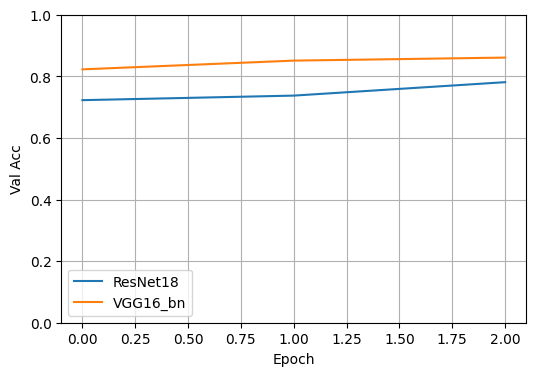

In [ ]:

# Plot validation accuracy
plt.figure(figsize=(6,4))
plt.plot(hist_res["val_acc"], label="ResNet18")
plt.plot(hist_vgg["val_acc"], label="VGG16_bn")
plt.xlabel("Epoch"); plt.ylabel("Val Acc"); plt.ylim(0,1); plt.legend(); plt.grid(True); plt.show()



## Part C — Test set accuracy


In [ ]:

criterion = torch.nn.CrossEntropyLoss()
te_loss_res, te_acc_res = evaluate(resnet18, test_loader, criterion)
te_loss_vgg, te_acc_vgg = evaluate(vgg16,   test_loader, criterion)
print(f"ResNet18 — Test acc: {te_acc_res:.3f}")
print(f"VGG16_bn — Test acc: {te_acc_vgg:.3f}")


ResNet18 — Test acc: 0.791
VGG16_bn — Test acc: 0.860



## Part D — Grad‑CAM on your images

Upload or pick test images and visualize class‑specific heatmaps using ResNet18.


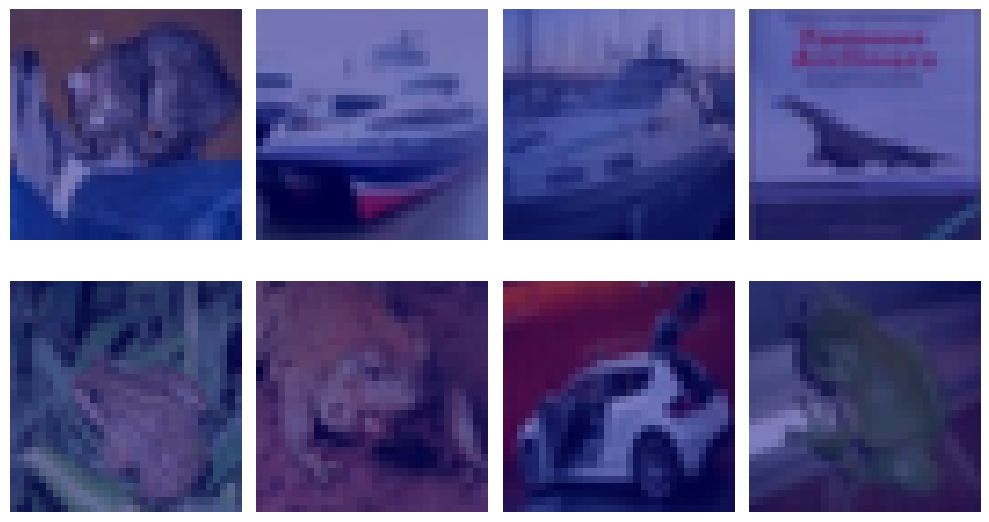

In [ ]:
import torch.nn.functional as F
from torchvision.utils import make_grid
import torchvision.transforms as T

# Simple Grad-CAM for ResNet-like models (last conv layer)
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model.eval()
        self.activations = None
        self.gradients = None
        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, inp, out):
        self.activations = out.detach()

    def save_gradient(self, module, grad_in, grad_out):
        self.gradients = grad_out[0].detach()

    def __call__(self, x, class_idx=None):
        x = x.requires_grad_(True)
        logits = self.model(x)
        if class_idx is None:
            class_idx = logits.argmax(1)
        loss = logits[torch.arange(x.size(0)), class_idx].sum()
        self.model.zero_grad(); loss.backward()

        # Global average pool the gradients
        weights = self.gradients.mean(dim=(2,3), keepdim=True)  # [B,C,1,1]
        cam = (weights * self.activations).sum(dim=1)           # [B,H,W]
        cam = F.relu(cam)
        # Normalize 0..1
        cam_min = cam.min(dim=2, keepdim=True).values.min(dim=1, keepdim=True).values
        cam_max = cam.max(dim=2, keepdim=True).values.max(dim=1, keepdim=True).values
        cam -= cam_min
        cam /= (cam_max + 1e-6)
        return cam.cpu()

# Prepare a few images (from CIFAR10 test) for demo
inv_norm = T.Normalize(mean=[-m/s for m,s in zip((0.4914,0.4822,0.4465),(0.2023,0.1994,0.2010))],
                       std=[1/s for s in (0.2023,0.1994,0.2010)])
batch = next(iter(test_loader))[0][:8].to(device)
cam_engine = GradCAM(resnet18, target_layer=resnet18.layer4[-1])

cams = cam_engine(batch).detach()
imgs = inv_norm(batch).clamp(0,1).cpu().detach()

# Overlay CAM
overlays = []
for i in range(len(imgs)):
    img = (imgs[i].permute(1,2,0).numpy()*255).astype(np.uint8)
    heat = (cams[i].numpy()*255).astype(np.uint8)
    heat = cv2.applyColorMap(heat, cv2.COLORMAP_JET)
    heat = cv2.cvtColor(heat, cv2.COLOR_BGR2RGB)
    blend = (0.5*img + 0.5*heat).astype(np.uint8)
    overlays.append(blend/255.0)

imshow_grid(overlays, ncols=4, size=(10,6))


## Part E — U‑Net for Semantic Segmentation (Oxford‑IIIT Pet)

Implement a compact U‑Net and train a couple of epochs on the **Oxford‑IIIT Pet** segmentation task (3 classes: background/outline/pet).  
To keep runtime short, resize to **256×256** and train for **2 epochs**.



## Deliverables

1. **ResNet18 vs VGG16:** validation‑accuracy plot and **3 bullets** comparing speed/accuracy/params.  
2. **Grad‑CAM:** one grid of heatmaps with a **2–3 sentence** interpretation.  
3. **U-Net** Implementation and training results
4. *(Optional)* Bonus: freeze all but the final layer for 1 epoch, then unfreeze → does warm‑up help? Show numbers.


*Generated 2025-10-21 06:20 UTC*